# 🍔 ¿Dónde está mi hamburguesa?

## Regresión lineal con Machine Learning

Una aplicación de domicilios dice:

> **"Tu pedido llegará aproximadamente en 37 minutos."**

¿Cómo obtiene ese número?

En este notebook construiremos un modelo capaz de predecir el tiempo de entrega utilizando información como:

- Distancia.
- Clima.
- Tráfico.
- Momento del día.
- Tipo de vehículo.
- Tiempo de preparación.
- Experiencia del repartidor.

Recorreremos un pipeline completo de Machine Learning:

**Problema → Datos → Exploración → Preprocesamiento → Entrenamiento → Predicción → Evaluación → Interpretación**

## 1. Configuración

In [6]:
!pip -q install kagglehub

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("✅ Librerías cargadas")

✅ Librerías cargadas


## 2. Descargar el dataset

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "denkuznetz/food-delivery-time-prediction"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'food-delivery-time-prediction' dataset.
Path to dataset files: /kaggle/input/food-delivery-time-prediction


In [11]:
dataset_dir = Path(path)

csv_files = list(
    dataset_dir.rglob("*.csv")
)

print("Archivos CSV encontrados:")

for archivo in csv_files:
    print(" -", archivo)

Archivos CSV encontrados:
 - /kaggle/input/food-delivery-time-prediction/Food_Delivery_Times.csv


## 3. Encontrar el CSV

In [12]:
if len(csv_files) == 0:
    raise FileNotFoundError(
        "No se encontró ningún archivo CSV."
    )

csv_path = csv_files[0]

print("✅ Archivo seleccionado:")
print(csv_path)


✅ Archivo seleccionado:
/kaggle/input/food-delivery-time-prediction/Food_Delivery_Times.csv


## 4. Cargar el dataset

In [13]:
df = pd.read_csv(csv_path)

print("✅ Dataset cargado")

✅ Dataset cargado


In [14]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## 5. Primera inspección

In [15]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 1000
Columnas: 9


In [16]:
df.columns.tolist()

['Order_ID',
 'Distance_km',
 'Weather',
 'Traffic_Level',
 'Time_of_Day',
 'Vehicle_Type',
 'Preparation_Time_min',
 'Courier_Experience_yrs',
 'Delivery_Time_min']

Verificar estructura esperada

Esta celda es útil para detectar inmediatamente si Kaggle cambia el dataset.

In [17]:
columnas_esperadas = [
    "Order_ID",
    "Distance_km",
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]

faltantes = [
    columna
    for columna in columnas_esperadas
    if columna not in df.columns
]

if faltantes:
    print("⚠️ No se encontraron estas columnas:")
    print(faltantes)
else:
    print("✅ Todas las columnas esperadas están disponibles.")

✅ Todas las columnas esperadas están disponibles.


Tipos y nulos

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


Estadísticas numéricas

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order_ID,1000.0,500.500000,288.819436,1.00,250.750,500.50,750.2500,1000.00
Distance_km,1000.0,10.059970,5.696656,0.59,5.105,10.19,15.0175,19.99
Preparation_Time_min,1000.0,16.982000,7.204553,5.00,11.000,17.00,23.0000,29.00
Courier_Experience_yrs,970.0,4.579381,2.914394,0.00,2.000,5.00,7.0000,9.00
Delivery_Time_min,1000.0,56.732000,22.070915,8.00,41.000,55.50,71.0000,153.00


Estadísticas generales

In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
Distance_km,1000.0,NaN,NaN,NaN,10.05997,5.696656,0.59,5.105,10.19,15.0175,19.99
Weather,970,5,Clear,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traffic_Level,970,3,Medium,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_of_Day,970,4,Morning,308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,1000,3,Bike,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Preparation_Time_min,1000.0,NaN,NaN,NaN,16.982,7.204553,5.0,11.0,17.0,23.0,29.0
Courier_Experience_yrs,970.0,NaN,NaN,NaN,4.579381,2.914394,0.0,2.0,5.0,7.0,9.0
Delivery_Time_min,1000.0,NaN,NaN,NaN,56.732,22.070915,8.0,41.0,55.5,71.0,153.0


## 6. Calidad de los datos

Valores faltantes

In [21]:
nulos = df.isnull().sum()

nulos

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


Solo columnas con faltantes

In [22]:
nulos[nulos > 0]

,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Courier_Experience_yrs,30


Porcentaje de faltantes

In [23]:
porcentaje_nulos = (
    df.isnull().mean() * 100
).round(2)

pd.DataFrame({
    "Valores_faltantes": nulos,
    "Porcentaje": porcentaje_nulos
}).sort_values(
    "Valores_faltantes",
    ascending=False
)

,Valores_faltantes,Porcentaje
Weather,30,3.0
Time_of_Day,30,3.0
Traffic_Level,30,3.0
Courier_Experience_yrs,30,3.0
Order_ID,0,0.0
Distance_km,0,0.0
Vehicle_Type,0,0.0
Preparation_Time_min,0,0.0
Delivery_Time_min,0,0.0


Duplicados

In [24]:
duplicados = df.duplicated().sum()

print(
    f"Registros duplicados: {duplicados}"
)

Registros duplicados: 0


Valores únicos

In [25]:
df.nunique().sort_values()

,0
Traffic_Level,3
Vehicle_Type,3
Time_of_Day,4
Weather,5
Courier_Experience_yrs,10
Preparation_Time_min,25
Delivery_Time_min,108
Distance_km,785
Order_ID,1000


## 7. Explorar variables categóricas

In [26]:
categorical_features = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]

for columna in categorical_features:

    print("=" * 50)
    print(columna)

    print(
        df[columna]
        .value_counts(
            dropna=False
        )
    )

    print()

Weather
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

Traffic_Level
Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64

Time_of_Day
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64

Vehicle_Type
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64



## 8. Visualización inicial

Distribución del target

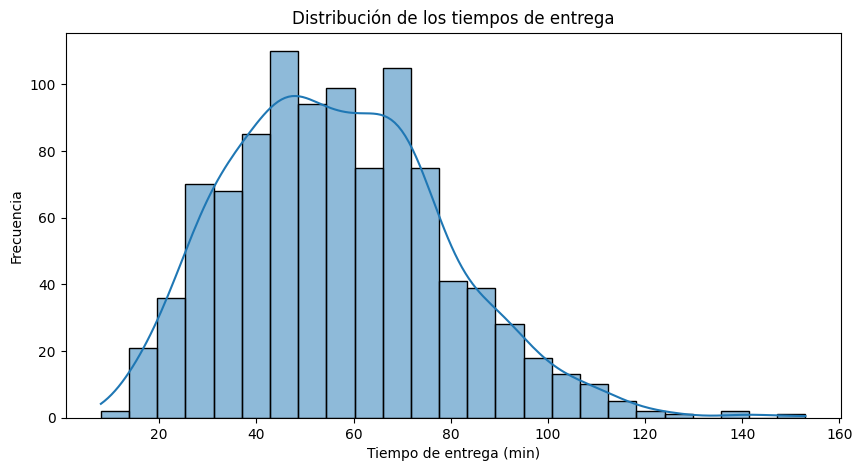

In [27]:
plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    data=df,
    x="Delivery_Time_min",
    kde=True
)

plt.title(
    "Distribución de los tiempos de entrega"
)

plt.xlabel(
    "Tiempo de entrega (min)"
)

plt.ylabel(
    "Frecuencia"
)

plt.show()

Preguntas
¿Dónde se concentra la mayoría de pedidos?
¿Hay tiempos extremadamente altos?
¿La distribución parece simétrica?

## 9. Estadísticas del target

In [28]:
df["Delivery_Time_min"].describe()

,Delivery_Time_min
count,1000.000000
mean,56.732000
std,22.070915
min,8.000000
25%,41.000000
50%,55.500000
75%,71.000000
max,153.000000


## 10. Primera hipótesis

Entre más lejos esté el cliente, más debería tardar el pedido.

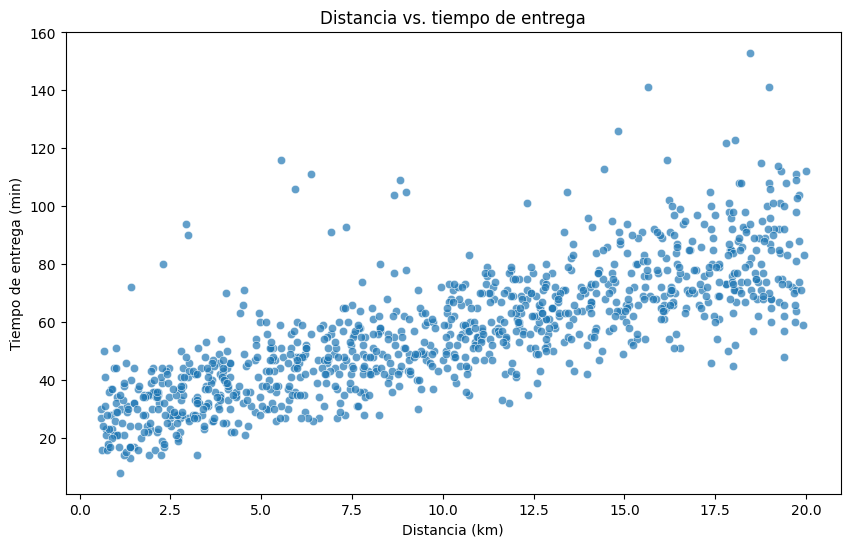

In [29]:
plt.figure(
    figsize=(10, 6)
)

sns.scatterplot(
    data=df,
    x="Distance_km",
    y="Delivery_Time_min",
    alpha=0.7
)

plt.title(
    "Distancia vs. tiempo de entrega"
)

plt.xlabel(
    "Distancia (km)"
)

plt.ylabel(
    "Tiempo de entrega (min)"
)

plt.show()

## 11. Correlación

In [30]:
correlacion = df[
    [
        "Distance_km",
        "Delivery_Time_min"
    ]
].corr()

correlacion

,Distance_km,Delivery_Time_min
Distance_km,1.000000,0.780998
Delivery_Time_min,0.780998,1.000000


In [31]:
corr_distancia = df[
    "Distance_km"
].corr(
    df["Delivery_Time_min"]
)

print(
    f"Correlación distancia-tiempo: "
    f"{corr_distancia:.3f}"
)

Correlación distancia-tiempo: 0.781


## 12. Explorar otras variables numéricas

Preparación

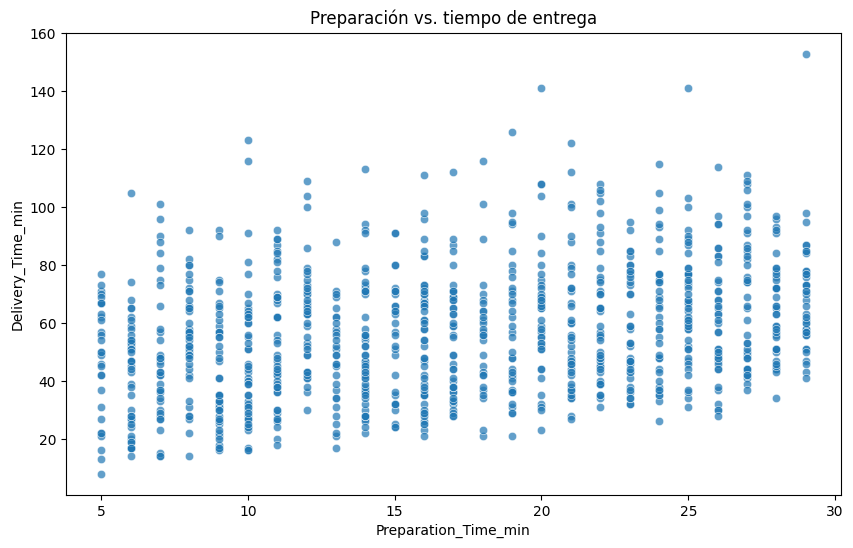

In [32]:
plt.figure(
    figsize=(10, 6)
)

sns.scatterplot(
    data=df,
    x="Preparation_Time_min",
    y="Delivery_Time_min",
    alpha=0.7
)

plt.title(
    "Preparación vs. tiempo de entrega"
)

plt.show()

Experiencia

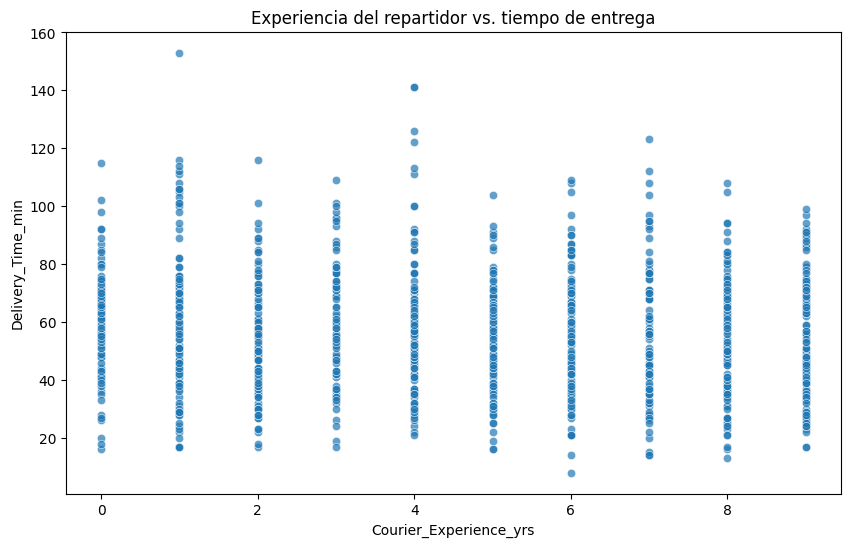

In [33]:
plt.figure(
    figsize=(10, 6)
)

sns.scatterplot(
    data=df,
    x="Courier_Experience_yrs",
    y="Delivery_Time_min",
    alpha=0.7
)

plt.title(
    "Experiencia del repartidor vs. tiempo de entrega"
)

plt.show()

## 13. Explorar una variable categórica

Tráfico

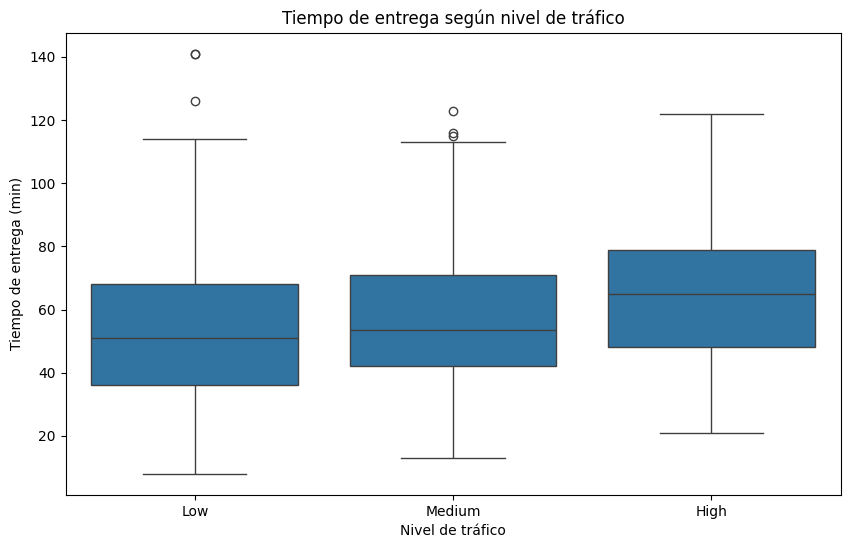

In [34]:
plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=df,
    x="Traffic_Level",
    y="Delivery_Time_min"
)

plt.title(
    "Tiempo de entrega según nivel de tráfico"
)

plt.xlabel(
    "Nivel de tráfico"
)

plt.ylabel(
    "Tiempo de entrega (min)"
)

plt.show()

Clima

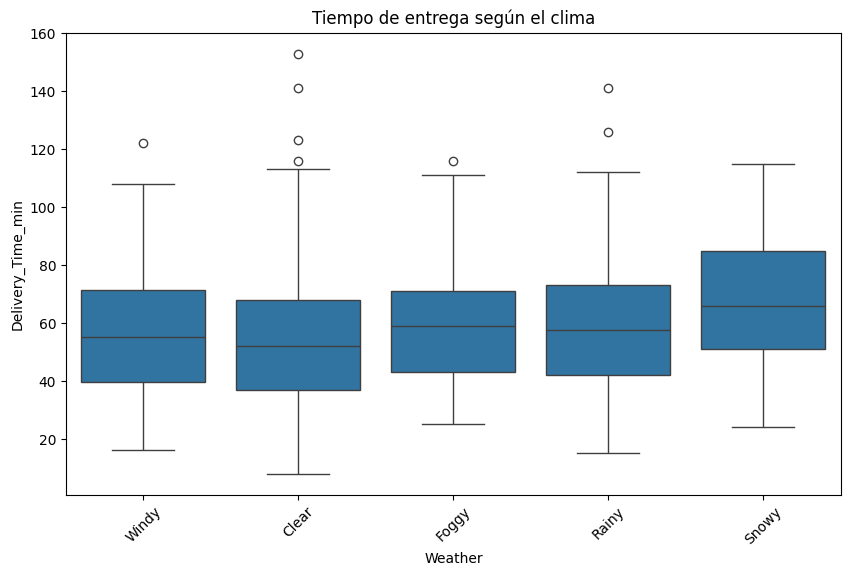

In [35]:
plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=df,
    x="Weather",
    y="Delivery_Time_min"
)

plt.title(
    "Tiempo de entrega según el clima"
)

plt.xticks(
    rotation=45
)

plt.show()

## 14. Matriz de correlación numérica

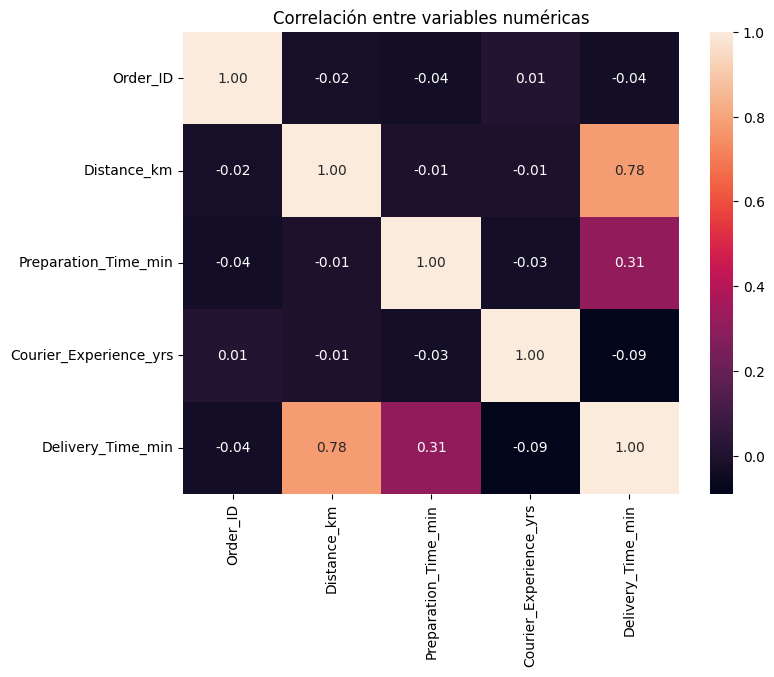

In [36]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title(
    "Correlación entre variables numéricas"
)

plt.show()

## 15. Definir X e y

In [37]:
numeric_features = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs"
]

categorical_features = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]

features = (
    numeric_features
    + categorical_features
)

X = df[features].copy()

y = df[
    "Delivery_Time_min"
].copy()

In [38]:
print(
    "Dimensiones de X:",
    X.shape
)

print(
    "Dimensiones de y:",
    y.shape
)

X.head()

Dimensiones de X: (1000, 7)
Dimensiones de y: (1000,)


,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather,Traffic_Level,Time_of_Day,Vehicle_Type
0,7.93,12,1.0,Windy,Low,Afternoon,Scooter
1,16.42,20,2.0,Clear,Medium,Evening,Bike
2,9.52,28,1.0,Foggy,Low,Night,Scooter
3,7.44,5,1.0,Rainy,Medium,Afternoon,Scooter
4,19.03,16,5.0,Clear,Low,Morning,Bike


## 16. Train / Test

Usaremos una partición 80/20. train_test_split es la utilidad estándar de scikit-learn para crear estos subconjuntos

In [39]:
from sklearn.model_selection import (
    train_test_split
)

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

In [40]:
print(
    "Entrenamiento:",
    X_train.shape
)

print(
    "Prueba:",
    X_test.shape
)

Entrenamiento: (800, 7)
Prueba: (200, 7)


## 17. Modelo 1 — Solo distancia

In [41]:
X_train_simple = X_train[
    ["Distance_km"]
]

X_test_simple = X_test[
    ["Distance_km"]
]

Entrenar

In [42]:
from sklearn.linear_model import (
    LinearRegression
)

modelo_simple = LinearRegression()

modelo_simple.fit(
    X_train_simple,
    y_train
)

print(
    "✅ Modelo entrenado"
)

✅ Modelo entrenado


## 18. ¿Qué aprendió?

In [43]:
intercepto = (
    modelo_simple.intercept_
)

pendiente = (
    modelo_simple.coef_[0]
)

print(
    f"Intercepto: {intercepto:.4f}"
)

print(
    f"Pendiente: {pendiente:.4f}"
)

Intercepto: 26.5857
Pendiente: 3.0165


Ecuación

In [44]:
print(
    "Modelo aprendido:"
)

print(
    f"Tiempo = "
    f"{pendiente:.2f} × Distancia "
    f"+ {intercepto:.2f}"
)

Modelo aprendido:
Tiempo = 3.02 × Distancia + 26.59


## 19. Predicciones simples

In [45]:
y_pred_simple = (
    modelo_simple.predict(
        X_test_simple
    )
)

## 20. Visualizar la recta

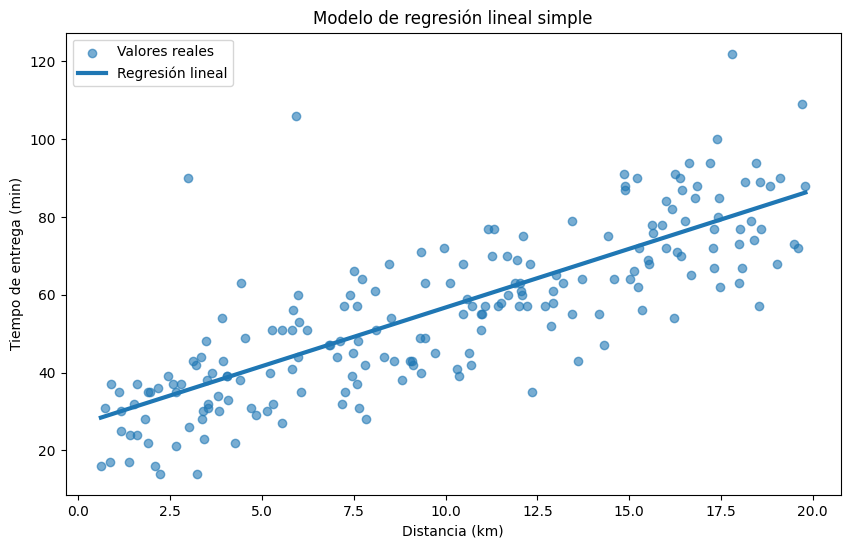

In [46]:
orden = np.argsort(
    X_test_simple[
        "Distance_km"
    ].values
)

plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    X_test_simple[
        "Distance_km"
    ],
    y_test,
    alpha=0.6,
    label="Valores reales"
)

plt.plot(
    X_test_simple[
        "Distance_km"
    ].values[orden],

    y_pred_simple[orden],

    linewidth=3,

    label="Regresión lineal"
)

plt.xlabel(
    "Distancia (km)"
)

plt.ylabel(
    "Tiempo de entrega (min)"
)

plt.title(
    "Modelo de regresión lineal simple"
)

plt.legend()

plt.show()

## 21. Comparar real vs. predicho

In [47]:
resultados_simple = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred_simple
})

resultados_simple[
    "Error"
] = (
    resultados_simple["Real"]
    - resultados_simple["Predicho"]
)

resultados_simple[
    "Error_absoluto"
] = (
    resultados_simple[
        "Error"
    ].abs()
)

resultados_simple.head(10)

,Real,Predicho,Error,Error_absoluto
0,32,42.573037,-10.573037,10.573037
1,68,58.138020,9.861980,9.861980
2,39,38.772285,0.227715,0.227715
3,44,36.630592,7.369408,7.369408
4,85,79.192978,5.807022,5.807022
5,31,28.727442,2.272558,2.272558
6,77,60.249549,16.750451,16.750451
7,33,38.892944,-5.892944,5.892944
8,90,35.604992,54.395008,54.395008
9,91,75.603379,15.396621,15.396621


## 22. Métricas

In [48]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Función de evaluación

In [49]:
def evaluar_modelo(
    y_real,
    y_pred
):

    mae = mean_absolute_error(
        y_real,
        y_pred
    )

    mse = mean_squared_error(
        y_real,
        y_pred
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        y_real,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [50]:
metricas_simple = evaluar_modelo(
    y_test,
    y_pred_simple
)

metricas_simple

{'MAE': 9.580954148917813,
 'RMSE': np.float64(12.576246151884975),
 'R2': 0.6471386683659509}

Mostrar bonito

In [51]:
print(
    "📊 MODELO SIMPLE"
)

print(
    f"MAE:  "
    f"{metricas_simple['MAE']:.2f} minutos"
)

print(
    f"RMSE: "
    f"{metricas_simple['RMSE']:.2f} minutos"
)

print(
    f"R²:   "
    f"{metricas_simple['R2']:.4f}"
)

📊 MODELO SIMPLE
MAE:  9.58 minutos
RMSE: 12.58 minutos
R²:   0.6471


## 23. El problema del modelo simple

## 🤔 Dos pedidos idénticos... según nuestro modelo

### Pedido A

- Distancia: 10 km
- Clima: Clear
- Tráfico: Low
- Preparación: 8 min
- Repartidor: 8 años de experiencia

### Pedido B

- Distancia: 10 km
- Clima: Rainy
- Tráfico: High
- Preparación: 25 min
- Repartidor: 1 año de experiencia

Nuestro modelo solamente observa:

**Distancia = 10 km**

Por lo tanto, predice prácticamente lo mismo para ambos.

Necesitamos más información.

## 24. Regresión múltiple

Ahora utilizaremos todas las variables.

Pero tenemos dos problemas:


Variables numéricas


8.5


18


3


Variables Categóricas


Rainy


High


Evening


Scooter

La regresión necesita una representación numérica.

## 25. Ver los valores faltantes de Train

In [52]:
X_train.isnull().sum()

,0
Distance_km,0
Preparation_Time_min,0
Courier_Experience_yrs,24
Weather,22
Traffic_Level,19
Time_of_Day,24
Vehicle_Type,0


## 26. Pipelines numérico y categórico

Imports

In [53]:
from sklearn.impute import (
    SimpleImputer
)

from sklearn.preprocessing import (
    OneHotEncoder
)

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.pipeline import (
    Pipeline
)

## 27. Pipeline numérico

In [54]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

## 28. Pipeline categórico

In [55]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

## 29. ColumnTransformer

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 30. Visualizar conceptualmente

### Nuestro preprocesamiento

```text
DATOS
 │
 ├── NUMÉRICAS
 │      │
 │      ├─ Distance_km
 │      ├─ Preparation_Time_min
 │      └─ Courier_Experience_yrs
 │             │
 │             ↓
 │       Imputar mediana
 │
 └── CATEGÓRICAS
        │
        ├─ Weather
        ├─ Traffic_Level
        ├─ Time_of_Day
        └─ Vehicle_Type
               │
               ↓
        Imputar categoría
          más frecuente
               │
               ↓
        OneHotEncoder
               │
               ↓
         DATOS NUMÉRICOS

## 31. Pipeline completo

In [57]:
modelo_completo = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regression",
            LinearRegression()
        )
    ]
)

## 32. Ver el pipeline

In [58]:
modelo_completo

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Distance_km',
                                                   'Preparation_Time_min',
                                                   'Courier_Experience_yrs']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weather', 'Traffic_Level',
                                                   'Time_of_Day',
                                                   'Vehicle_Type'])])),
                ('regression', LinearRegression())])

## 33. Entrenar

In [59]:
modelo_completo.fit(
    X_train,
    y_train
)

print(
    "✅ Pipeline y modelo entrenados"
)

✅ Pipeline y modelo entrenados


## 34. Predecir

In [60]:
y_pred_completo = (
    modelo_completo.predict(
        X_test
    )
)

## 35. Evaluar modelo completo

In [61]:
metricas_completo = (
    evaluar_modelo(
        y_test,
        y_pred_completo
    )
)

metricas_completo

{'MAE': 6.063414905264765,
 'RMSE': np.float64(8.952170614738876),
 'R2': 0.8212036240893484}

In [62]:
print(
    "📊 MODELO COMPLETO"
)

print(
    f"MAE:  "
    f"{metricas_completo['MAE']:.2f} minutos"
)

print(
    f"RMSE: "
    f"{metricas_completo['RMSE']:.2f} minutos"
)

print(
    f"R²:   "
    f"{metricas_completo['R2']:.4f}"
)

📊 MODELO COMPLETO
MAE:  6.06 minutos
RMSE: 8.95 minutos
R²:   0.8212


## 36. Simple vs. completo

In [63]:
comparacion = pd.DataFrame([
    {
        "Modelo":
            "Solo distancia",

        **metricas_simple
    },
    {
        "Modelo":
            "Todas las variables",

        **metricas_completo
    }
])

comparacion

,Modelo,MAE,RMSE,R2
0,Solo distancia,9.580954,12.576246,0.647139
1,Todas las variables,6.063415,8.952171,0.821204


## 37. Visualizar comparación

MAE

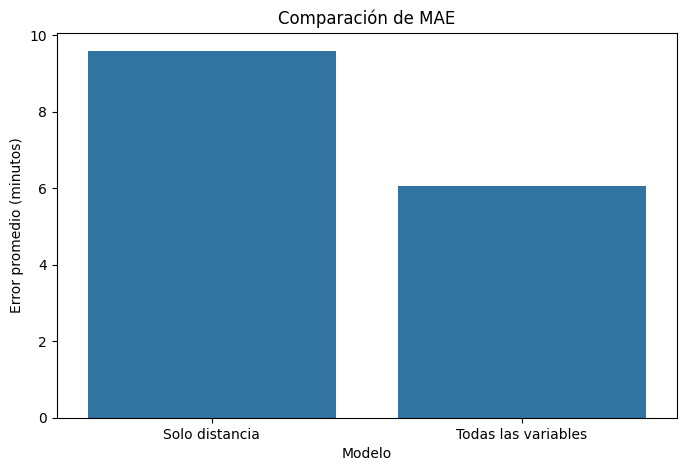

In [64]:
plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=comparacion,
    x="Modelo",
    y="MAE"
)

plt.title(
    "Comparación de MAE"
)

plt.ylabel(
    "Error promedio (minutos)"
)

plt.show()

R²


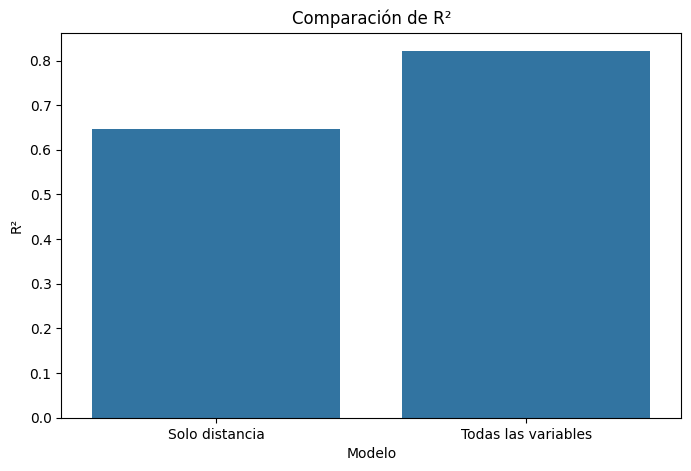

In [65]:
plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=comparacion,
    x="Modelo",
    y="R2"
)

plt.title(
    "Comparación de R²"
)

plt.ylabel(
    "R²"
)

plt.show()

## 38. Real vs. predicho

In [66]:
resultados = pd.DataFrame(
    index=X_test.index
)

resultados[
    "Tiempo_real"
] = y_test

resultados[
    "Tiempo_predicho"
] = y_pred_completo

resultados[
    "Error"
] = (
    resultados["Tiempo_real"]
    - resultados["Tiempo_predicho"]
)

resultados[
    "Error_absoluto"
] = (
    resultados[
        "Error"
    ].abs()
)

resultados.head(10)

,Tiempo_real,Tiempo_predicho,Error,Error_absoluto
521,32,35.650999,-3.650999,3.650999
737,68,61.268365,6.731635,6.731635
740,39,44.543129,-5.543129,5.543129
660,44,43.800204,0.199796,0.199796
411,85,80.639241,4.360759,4.360759
678,31,32.600398,-1.600398,1.600398
626,77,69.208358,7.791642,7.791642
513,33,32.364291,0.635709,0.635709
859,90,37.294282,52.705718,52.705718
136,91,77.909966,13.090034,13.090034


## 39. Gráfico real vs. predicho


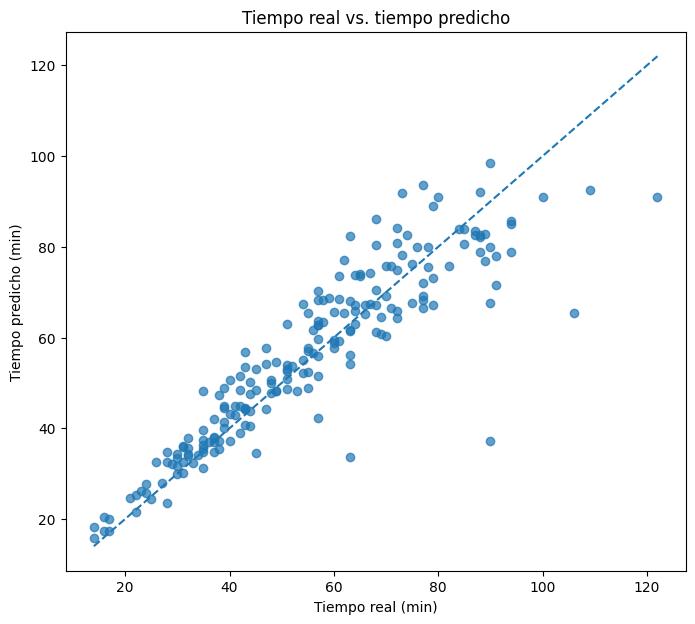

In [67]:
plt.figure(
    figsize=(8, 7)
)

plt.scatter(
    resultados[
        "Tiempo_real"
    ],
    resultados[
        "Tiempo_predicho"
    ],
    alpha=0.7
)

minimo = min(
    resultados[
        "Tiempo_real"
    ].min(),

    resultados[
        "Tiempo_predicho"
    ].min()
)

maximo = max(
    resultados[
        "Tiempo_real"
    ].max(),

    resultados[
        "Tiempo_predicho"
    ].max()
)

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

plt.xlabel(
    "Tiempo real (min)"
)

plt.ylabel(
    "Tiempo predicho (min)"
)

plt.title(
    "Tiempo real vs. tiempo predicho"
)

plt.show()

## 40. Residuos


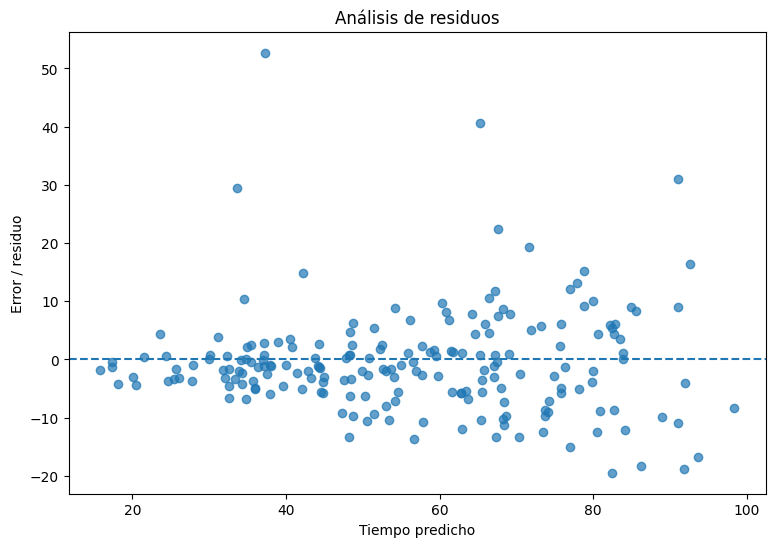

In [68]:
plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    resultados[
        "Tiempo_predicho"
    ],
    resultados[
        "Error"
    ],
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Tiempo predicho"
)

plt.ylabel(
    "Error / residuo"
)

plt.title(
    "Análisis de residuos"
)

plt.show()

## 41. ¿Dónde se equivoca más?

In [69]:
resultados.sort_values(
    "Error_absoluto",
    ascending=False
).head(10)

,Tiempo_real,Tiempo_predicho,Error,Error_absoluto
859,90,37.294282,52.705718,52.705718
570,106,65.305764,40.694236,40.694236
924,122,91.061430,30.938570,30.938570
318,63,33.591816,29.408184,29.408184
260,90,67.614030,22.385970,22.385970
310,63,82.452949,-19.452949,19.452949
973,91,71.597640,19.402360,19.402360
866,73,91.796194,-18.796194,18.796194
86,68,86.221492,-18.221492,18.221492
590,77,93.679571,-16.679571,16.679571


## 42. Recuperar toda la información de esos pedidos

In [70]:
analisis_errores = (
    X_test.copy()
)

analisis_errores[
    "Tiempo_real"
] = y_test

analisis_errores[
    "Tiempo_predicho"
] = y_pred_completo

analisis_errores[
    "Error"
] = (
    analisis_errores[
        "Tiempo_real"
    ]
    -
    analisis_errores[
        "Tiempo_predicho"
    ]
)

analisis_errores[
    "Error_absoluto"
] = (
    analisis_errores[
        "Error"
    ].abs()
)

In [71]:
peores_predicciones = (
    analisis_errores
    .sort_values(
        "Error_absoluto",
        ascending=False
    )
    .head(10)
)

peores_predicciones

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Tiempo_real,Tiempo_predicho,Error,Error_absoluto
859,2.99,9,5.0,Foggy,High,Afternoon,Bike,90,37.294282,52.705718,52.705718
570,5.93,27,1.0,Foggy,High,NaN,Scooter,106,65.305764,40.694236,40.694236
924,17.81,21,4.0,Windy,High,Evening,Bike,122,91.061430,30.938570,30.938570
318,4.43,10,1.0,Foggy,Low,Morning,Scooter,63,33.591816,29.408184,29.408184
260,16.38,7,NaN,Rainy,Medium,Night,Bike,90,67.614030,22.385970,22.385970
310,17.99,15,3.0,Snowy,Low,Afternoon,Bike,63,82.452949,-19.452949,19.452949
973,14.86,15,4.0,NaN,High,Night,Scooter,91,71.597640,19.402360,19.402360
866,19.50,18,2.0,Clear,High,Morning,Bike,73,91.796194,-18.796194,18.796194
86,19.03,26,5.0,Clear,Low,Afternoon,Car,68,86.221492,-18.221492,18.221492
590,18.60,28,9.0,Rainy,Medium,Morning,Car,77,93.679571,-16.679571,16.679571


## 43. El peor caso

In [72]:
peor_pedido = (
    analisis_errores
    .sort_values(
        "Error_absoluto",
        ascending=False
    )
    .iloc[0]
)

peor_pedido

,859
Distance_km,2.99
Preparation_Time_min,9
Courier_Experience_yrs,5.0
Weather,Foggy
Traffic_Level,High
Time_of_Day,Afternoon
Vehicle_Type,Bike
Tiempo_real,90
Tiempo_predicho,37.294282
Error,52.705718


## 44. ¿Qué hizo OneHotEncoder?

In [73]:
nombres_features = (
    modelo_completo
    .named_steps[
        "preprocessor"
    ]
    .get_feature_names_out()
)

print(
    "Número de features originales:",
    len(features)
)

print(
    "Número de features después del preprocesamiento:",
    len(nombres_features)
)

Número de features originales: 7
Número de features después del preprocesamiento: 18


In [74]:
nombres_features

array(['num__Distance_km', 'num__Preparation_Time_min',
       'num__Courier_Experience_yrs', 'cat__Weather_Clear',
       'cat__Weather_Foggy', 'cat__Weather_Rainy', 'cat__Weather_Snowy',
       'cat__Weather_Windy', 'cat__Traffic_Level_High',
       'cat__Traffic_Level_Low', 'cat__Traffic_Level_Medium',
       'cat__Time_of_Day_Afternoon', 'cat__Time_of_Day_Evening',
       'cat__Time_of_Day_Morning', 'cat__Time_of_Day_Night',
       'cat__Vehicle_Type_Bike', 'cat__Vehicle_Type_Car',
       'cat__Vehicle_Type_Scooter'], dtype=object)

## 45. Ver el dataset transformado

In [75]:
X_train_transformado = (
    modelo_completo
    .named_steps[
        "preprocessor"
    ]
    .transform(
        X_train
    )
)

print(
    "Antes:",
    X_train.shape
)

print(
    "Después:",
    X_train_transformado.shape
)

Antes: (800, 7)
Después: (800, 18)


## 46. Convertir el preprocesamiento a DataFrame

In [76]:
if hasattr(
    X_train_transformado,
    "toarray"
):
    X_visual = (
        X_train_transformado
        .toarray()
    )
else:
    X_visual = (
        X_train_transformado
    )

In [77]:
df_transformado = pd.DataFrame(
    X_visual,
    columns=nombres_features,
    index=X_train.index
)

df_transformado.head()

,num__Distance_km,num__Preparation_Time_min,num__Courier_Experience_yrs,cat__Weather_Clear,cat__Weather_Foggy,cat__Weather_Rainy,cat__Weather_Snowy,cat__Weather_Windy,cat__Traffic_Level_High,cat__Traffic_Level_Low,cat__Traffic_Level_Medium,cat__Time_of_Day_Afternoon,cat__Time_of_Day_Evening,cat__Time_of_Day_Morning,cat__Time_of_Day_Night,cat__Vehicle_Type_Bike,cat__Vehicle_Type_Car,cat__Vehicle_Type_Scooter
29,18.05,10.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
535,2.14,18.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
695,3.23,17.0,9.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
557,7.51,27.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
836,4.62,8.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 47. Volvemos a la hamburguesa 🍔

In [78]:
nuevo_pedido = pd.DataFrame([
    {
        "Distance_km": 8.5,
        "Weather": "Rainy",
        "Traffic_Level": "High",
        "Time_of_Day": "Evening",
        "Vehicle_Type": "Scooter",
        "Preparation_Time_min": 18,
        "Courier_Experience_yrs": 1
    }
])

nuevo_pedido

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,8.5,Rainy,High,Evening,Scooter,18,1


## 48. Predicción final

In [79]:
prediccion = (
    modelo_completo.predict(
        nuevo_pedido
    )
)

print(
    "🍔 Tiempo estimado:"
)

print(
    f"{prediccion[0]:.1f} minutos"
)

🍔 Tiempo estimado:
64.4 minutos


## 49. Crear función para probar pedidos

In [80]:
def predecir_entrega(
    distancia,
    clima,
    trafico,
    momento,
    vehiculo,
    preparacion,
    experiencia
):

    pedido = pd.DataFrame([
        {
            "Distance_km":
                distancia,

            "Weather":
                clima,

            "Traffic_Level":
                trafico,

            "Time_of_Day":
                momento,

            "Vehicle_Type":
                vehiculo,

            "Preparation_Time_min":
                preparacion,

            "Courier_Experience_yrs":
                experiencia
        }
    ])

    tiempo = (
        modelo_completo
        .predict(
            pedido
        )[0]
    )

    print(
        f"🛵 Tiempo estimado: "
        f"{tiempo:.1f} minutos"
    )

    return tiempo

## 50. Experimento 1

In [81]:
predecir_entrega(
    distancia=8.5,
    clima="Rainy",
    trafico="High",
    momento="Evening",
    vehiculo="Scooter",
    preparacion=18,
    experiencia=1
)

🛵 Tiempo estimado: 64.4 minutos


np.float64(64.38278147499946)

## 51. Experimento 2 — Mismo pedido, menos tráfico

In [82]:
predecir_entrega(
    distancia=8.5,
    clima="Rainy",
    trafico="Low",
    momento="Evening",
    vehiculo="Scooter",
    preparacion=18,
    experiencia=1
)

🛵 Tiempo estimado: 53.7 minutos


np.float64(53.703191192097165)

## 52. Experimento 3 — Mucho más lejos

In [83]:
predecir_entrega(
    distancia=18,
    clima="Rainy",
    trafico="High",
    momento="Evening",
    vehiculo="Scooter",
    preparacion=18,
    experiencia=1
)

🛵 Tiempo estimado: 92.9 minutos


np.float64(92.92137448882724)

## 53. Experimento 4 — Preparación absurda

In [84]:
predecir_entrega(
    distancia=8.5,
    clima="Rainy",
    trafico="High",
    momento="Evening",
    vehiculo="Scooter",
    preparacion=60,
    experiencia=1
)

🛵 Tiempo estimado: 105.2 minutos


np.float64(105.21731604065519)

## 54. Experimento 5 — Drone 🚁

Como usamos handle_unknown="ignore", OneHotEncoder puede procesar categorías desconocidas sin lanzar el error predeterminado. Eso no significa que el modelo haya aprendido el comportamiento de esa categoría.

In [85]:
predecir_entrega(
    distancia=8.5,
    clima="Rainy",
    trafico="High",
    momento="Evening",
    vehiculo="Drone",
    preparacion=18,
    experiencia=1
)

🛵 Tiempo estimado: 65.2 minutos


np.float64(65.15719696942509)

La pregunta aquí es buenísima:

¿Que Python haya producido un número significa que la predicción tiene sentido?

No necesariamente.

## 55. Comparar varios escenarios automáticamente

In [86]:
escenarios = pd.DataFrame([
    {
        "Escenario": "Pedido normal",
        "Distance_km": 8.5,
        "Weather": "Rainy",
        "Traffic_Level": "High",
        "Time_of_Day": "Evening",
        "Vehicle_Type": "Scooter",
        "Preparation_Time_min": 18,
        "Courier_Experience_yrs": 1
    },
    {
        "Escenario": "Sin tráfico",
        "Distance_km": 8.5,
        "Weather": "Rainy",
        "Traffic_Level": "Low",
        "Time_of_Day": "Evening",
        "Vehicle_Type": "Scooter",
        "Preparation_Time_min": 18,
        "Courier_Experience_yrs": 1
    },
    {
        "Escenario": "Más lejos",
        "Distance_km": 18,
        "Weather": "Rainy",
        "Traffic_Level": "High",
        "Time_of_Day": "Evening",
        "Vehicle_Type": "Scooter",
        "Preparation_Time_min": 18,
        "Courier_Experience_yrs": 1
    }
])

In [87]:
X_escenarios = escenarios.drop(
    columns="Escenario"
)

escenarios[
    "Tiempo_estimado"
] = (
    modelo_completo
    .predict(
        X_escenarios
    )
)

escenarios[
    [
        "Escenario",
        "Tiempo_estimado"
    ]
]

,Escenario,Tiempo_estimado
0,Pedido normal,64.382781
1,Sin tráfico,53.703191
2,Más lejos,92.921374


## 56. Inspeccionar coeficientes — opcional

Aquí podemos mirar matemáticamente qué aprendió la regresión.

No lo usaría para afirmar causalidad, pero sí es interesante para mostrar el interior del modelo.

In [88]:
regresion = (
    modelo_completo
    .named_steps[
        "regression"
    ]
)

coeficientes = (
    regresion.coef_
)

len(coeficientes)

18

In [89]:
tabla_coeficientes = pd.DataFrame({
    "Feature":
        nombres_features,

    "Coeficiente":
        coeficientes
})

tabla_coeficientes

,Feature,Coeficiente
0,num__Distance_km,3.004062
1,num__Preparation_Time_min,0.972251
2,num__Courier_Experience_yrs,-0.683073
3,cat__Weather_Clear,-4.243399
4,cat__Weather_Foggy,1.460801
5,cat__Weather_Rainy,0.381834
6,cat__Weather_Snowy,5.038472
7,cat__Weather_Windy,-2.637708
8,cat__Traffic_Level_High,5.418788
9,cat__Traffic_Level_Low,-5.260802


Ordenar

In [90]:
tabla_coeficientes[
    "Magnitud"
] = (
    tabla_coeficientes[
        "Coeficiente"
    ].abs()
)

tabla_coeficientes.sort_values(
    "Magnitud",
    ascending=False
)

,Feature,Coeficiente,Magnitud
8,cat__Traffic_Level_High,5.418788,5.418788
9,cat__Traffic_Level_Low,-5.260802,5.260802
6,cat__Weather_Snowy,5.038472,5.038472
3,cat__Weather_Clear,-4.243399,4.243399
0,num__Distance_km,3.004062,3.004062
7,cat__Weather_Windy,-2.637708,2.637708
4,cat__Weather_Foggy,1.460801,1.460801
14,cat__Time_of_Day_Night,-1.179537,1.179537
12,cat__Time_of_Day_Evening,1.120236,1.120236
1,num__Preparation_Time_min,0.972251,0.972251


## 57. Baseline adicional — opcional pero muy bueno

Esta parte me gusta para que el R² deje de ser un número abstracto.

¿Qué pasaría si fuéramos extremadamente perezosos y para todos los pedidos predijéramos simplemente el promedio del conjunto de entrenamiento?

In [91]:
promedio_train = (
    y_train.mean()
)

y_pred_baseline = np.full(
    len(y_test),
    promedio_train
)

metricas_baseline = evaluar_modelo(
    y_test,
    y_pred_baseline
)

metricas_baseline

{'MAE': 17.50145,
 'RMSE': np.float64(21.23240569418595),
 'R2': -0.005774031253919842}

## 58. Comparación con baseline

In [92]:
comparacion_final = pd.DataFrame([
    {
        "Modelo":
            "Predecir promedio",

        **metricas_baseline
    },
    {
        "Modelo":
            "Solo distancia",

        **metricas_simple
    },
    {
        "Modelo":
            "Modelo completo",

        **metricas_completo
    }
])

comparacion_final

,Modelo,MAE,RMSE,R2
0,Predecir promedio,17.501450,21.232406,-0.005774
1,Solo distancia,9.580954,12.576246,0.647139
2,Modelo completo,6.063415,8.952171,0.821204


Esta tabla es probablemente una de las mejores de toda la clase.

Porque ahora pueden ver:

NO ML / BASELINE


      ↓


MODELO SIMPLE


      ↓


MODELO CON CONTEXTO


## 59. Visualización final

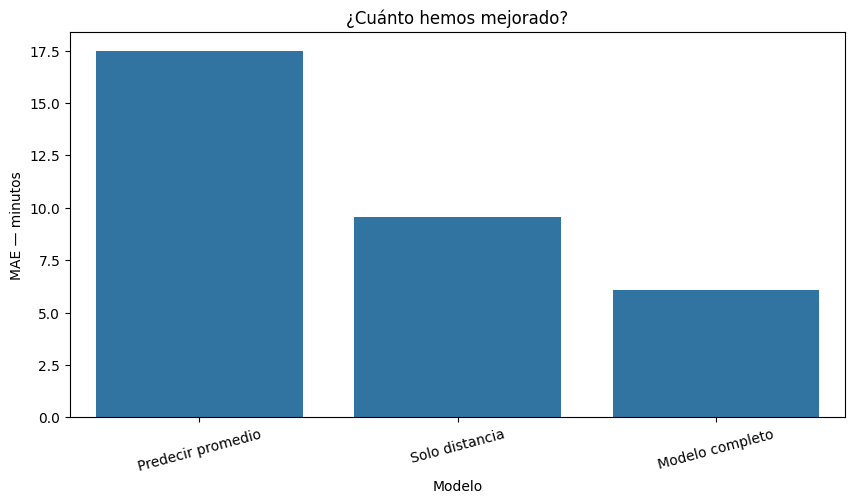

In [93]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=comparacion_final,
    x="Modelo",
    y="MAE"
)

plt.title(
    "¿Cuánto hemos mejorado?"
)

plt.ylabel(
    "MAE — minutos"
)

plt.xticks(
    rotation=15
)

plt.show()

## 60. Resumen automático

In [94]:
print(
    "=" * 60
)

print(
    "🍔 RESUMEN DEL EXPERIMENTO"
)

print(
    "=" * 60
)

print()

print(
    f"Baseline MAE: "
    f"{metricas_baseline['MAE']:.2f}"
)

print(
    f"Modelo simple MAE: "
    f"{metricas_simple['MAE']:.2f}"
)

print(
    f"Modelo completo MAE: "
    f"{metricas_completo['MAE']:.2f}"
)

print()

print(
    f"Modelo simple R²: "
    f"{metricas_simple['R2']:.3f}"
)

print(
    f"Modelo completo R²: "
    f"{metricas_completo['R2']:.3f}"
)

🍔 RESUMEN DEL EXPERIMENTO

Baseline MAE: 17.50
Modelo simple MAE: 9.58
Modelo completo MAE: 6.06

Modelo simple R²: 0.647
Modelo completo R²: 0.821


## 61. Preguntas finales

# 🧠 Antes de cerrar

Responde:

1. ¿Cuál era nuestro **target**?
2. ¿Por qué no utilizamos `Order_ID`?
3. ¿Qué aprendió realmente `LinearRegression`?
4. ¿Por qué necesitamos separar `Train` y `Test`?
5. ¿Qué significa el MAE en este problema?
6. ¿Por qué R² no significa "porcentaje de precisión"?
7. ¿Por qué no asignamos arbitrariamente `Rainy = 1`, `Sunny = 2`, etc.?
8. ¿Qué hace `OneHotEncoder`?
9. ¿Qué problema resuelve `SimpleImputer`?
10. ¿Por qué necesitamos `ColumnTransformer`?
11. ¿Qué ventaja tiene construir un `Pipeline`?
12. ¿Por qué el modelo puede predecir un pedido con `Vehicle_Type = "Drone"` y aun así no deberíamos confiar necesariamente en esa predicción?
13. ¿En qué pedidos se equivocó más?
14. ¿Qué variable agregarías al dataset para intentar mejorar el modelo?

## 62. Reto final

# 🏆 Reto: derrota al modelo

Encuentra o construye un pedido para el cual consideres que la predicción del modelo es absurda.

Debes presentar:

1. Las características del pedido.
2. La predicción obtenida.
3. Por qué consideras que la predicción es problemática.
4. Qué información le está faltando al modelo.
5. Qué cambio harías en los datos o en el sistema para mejorar esa situación.

> Un modelo no se comprende únicamente observando dónde acierta.
> También debemos descubrir dónde falla y por qué.